# 🍽️ Lyon Restaurants — Full Predictive Analytics Pipeline
**Data**: 8 000 transactions × 86 features | Lyon restaurant dataset  
**Goals**: Correlation analysis → Regression (Linear, Random Forest, Gradient Boosting) → Classification (Logit, Probit)  
**Split**: 80 % training / 20 % testing

---
## Table of Contents
1. Setup & Load Data  
2. Full Data Overview  
3. Correlation Analysis  
4. Preprocessing & Feature Engineering  
5. Regression Models & Comparison  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Load Data

In [ ]:
# ─────────────────────────────────────────────
# CELL 1 — Install & Import Libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                              accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve, f1_score)
from sklearn.inspection import permutation_importance
import statsmodels.api as sm           # for Probit

# Plot style
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

print("✅ All libraries loaded")
import sklearn; print(f"   sklearn  : {sklearn.__version__}")
print(f"   pandas   : {pd.__version__}")
print(f"   numpy    : {np.__version__}")
import statsmodels; print(f"   statsmodels: {statsmodels.__version__}")

✅ All libraries loaded
   sklearn  : 1.6.1
   pandas   : 2.2.2
   numpy    : 2.0.2
   statsmodels: 0.14.6


In [ ]:
# ─────────────────────────────────────────────
# CELL 2 — Load Data
# ─────────────────────────────────────────────
# ⚠️ Update FILE path if running in Google Colab:
#    from google.colab import drive; drive.mount('/content/drive')
FILE = "/content/drive/MyDrive/Colab Notebooks/lyon_restaurants_ETL_final.xlsx"

#FILE = "lyon_restaurants_ETL_final.xlsx"          # <- adjust if needed

xl = pd.read_excel(FILE, sheet_name=None)

print("📂 Sheets found:")
for name, df in xl.items():
    print(f"   • {name:30s}  →  {df.shape[0]:,} rows  ×  {df.shape[1]} cols")

# Work with the master Source_Raw table
df = xl['Source_Raw'].copy()
print(f"\n✅ Source_Raw loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")


📂 Sheets found:
   • Source_Raw                      →  8,000 rows  ×  86 cols
   • Dim_Restaurant                  →  400 rows  ×  14 cols
   • Dim_Location                    →  400 rows  ×  18 cols
   • Dim_Date                        →  1,096 rows  ×  9 cols
   • Dim_Customer                    →  1,953 rows  ×  7 cols
   • Dim_Dish                        →  1,925 rows  ×  8 cols
   • Dim_Review                      →  3,325 rows  ×  11 cols
   • Dim_Sentiment                   →  3,325 rows  ×  6 cols
   • Dim_Operations                  →  400 rows  ×  12 cols
   • Dim_Cost                        →  400 rows  ×  7 cols
   • Dim_Order                       →  8,000 rows  ×  6 cols
   • Fact_Restaurant                 →  5,929 rows  ×  15 cols
   • Fact_Reviews                    →  3,325 rows  ×  12 cols
   • Fact_Order                      →  8,000 rows  ×  14 cols

✅ Source_Raw loaded: 8,000 rows × 86 columns


## 2. Full Data Overview

In [ ]:
# ─────────────────────────────────────────────
# DATA PREVIEW — Head & Info
# ─────────────────────────────────────────────

print("\n📋 Dataset Info:")
df.info()




📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 86 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Transaction_ID                  8000 non-null   int64         
 1   Order_ID                        8000 non-null   int64         
 2   Review_ID                       3325 non-null   float64       
 3   Order_Date                      8000 non-null   datetime64[ns]
 4   Order_Year                      8000 non-null   int64         
 5   Order_Month                     8000 non-null   int64         
 6   Order_Month_Name                8000 non-null   object        
 7   Order_Quarter                   8000 non-null   int64         
 8   Order_Day                       8000 non-null   int64         
 9   Order_Weekday                   8000 non-null   object        
 10  Is_Weekend                      8000 non-null   int64  

In [ ]:
# ─────────────────────────────────────────────
# CELL 3 — Shape, Types & Missing Values
# ─────────────────────────────────────────────
print("=" * 55)
print(f"  Dataset shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print("=" * 55)

# Column type summary
dtype_counts = df.dtypes.value_counts()
print("\nColumn types:")
for dtype, count in dtype_counts.items():
    print(f"   {str(dtype):15s} : {count} columns")


# Missing values summary (only columns with missing)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"\nColumns with missing values ({len(missing)} total):")

miss_df = pd.DataFrame({
    'Missing': missing,
    'Pct (%)': (missing / len(df) * 100).round(1),
    'Type': df.dtypes[missing.index]   # 👈 add column types here
})

# Optional: reorder columns for readability
miss_df = miss_df[['Type', 'Missing', 'Pct (%)']]

print(miss_df.to_string())

  Dataset shape : 8,000 rows  ×  86 columns

Column types:
   object          : 33 columns
   int64           : 27 columns
   float64         : 24 columns
   datetime64[ns]  : 2 columns

Columns with missing values (10 total):
                      Type  Missing  Pct (%)
Negative_Keywords   object     6007     75.1
Review_ID          float64     4675     58.4
Sentiment_Score    float64     4675     58.4
Rating_Platform     object     4675     58.4
Review_Text         object     4675     58.4
Individual_Rating  float64     4675     58.4
Sentiment_Label     object     4675     58.4
Positive_Keywords   object     4675     58.4
Discount_Type       object     4320     54.0
Delivery_Partners   object     2241     28.0


In [ ]:
# ─────────────────────────────────────────────
# CELL 4 — Descriptive Statistics (numeric)
# ─────────────────────────────────────────────
key_numeric = [
    'Total_Revenue_EUR', 'Profit_EUR', 'Total_Cost_EUR',
    'Dish_Price_EUR', 'Order_Quantity', 'Discount_Amount_EUR',
    'Restaurant_Avg_Rating', 'Hygiene_Score',
    'Table_Occupancy_Rate_Peak', 'Table_Turnover_Rate',
    'Staff_Count_Per_Shift', 'Average_Wait_Time_Minutes',
    'Customer_Avg_Group_Size', 'Seating_Capacity',
    'Restaurant_Age_Years', 'Foot_Traffic_Volume'
]

print("📊 Descriptive Statistics — Key Numeric Variables")
print("=" * 70)
pd.set_option('display.float_format', '{:.2f}'.format)
desc = df[key_numeric].describe().T
desc['range'] = desc['max'] - desc['min']
print(desc[['count','mean','std','min','25%','50%','75%','max','range']].to_string())

📊 Descriptive Statistics — Key Numeric Variables
                            count   mean    std     min    25%   50%    75%     max   range
Total_Revenue_EUR         8000.00 144.52 134.06    8.09  53.12 98.16 188.94 1008.38 1000.29
Profit_EUR                8000.00 -10.68  21.36 -180.19 -15.04 -4.21   0.41   49.93  230.12
Total_Cost_EUR            8000.00 144.47 134.14    8.19  53.22 98.05 188.77 1011.07 1002.88
Dish_Price_EUR            8000.00  13.65  13.94    1.12   4.73  8.95  16.81   99.23   98.11
Order_Quantity            8000.00   2.99   1.42    1.00   2.00  3.00   4.00    5.00    4.00
Discount_Amount_EUR       8000.00  10.74  19.90    0.00   0.00  0.00  13.63  185.33  185.33
Restaurant_Avg_Rating     8000.00   3.93   0.51    2.30   3.50  4.00   4.30    5.00    2.70
Hygiene_Score             8000.00   8.21   0.80    6.80   7.60  8.20   8.80   10.00    3.20
Table_Occupancy_Rate_Peak 8000.00   0.65   0.08    0.40   0.59  0.66   0.71    0.88    0.48
Table_Turnover_Rate       8000.

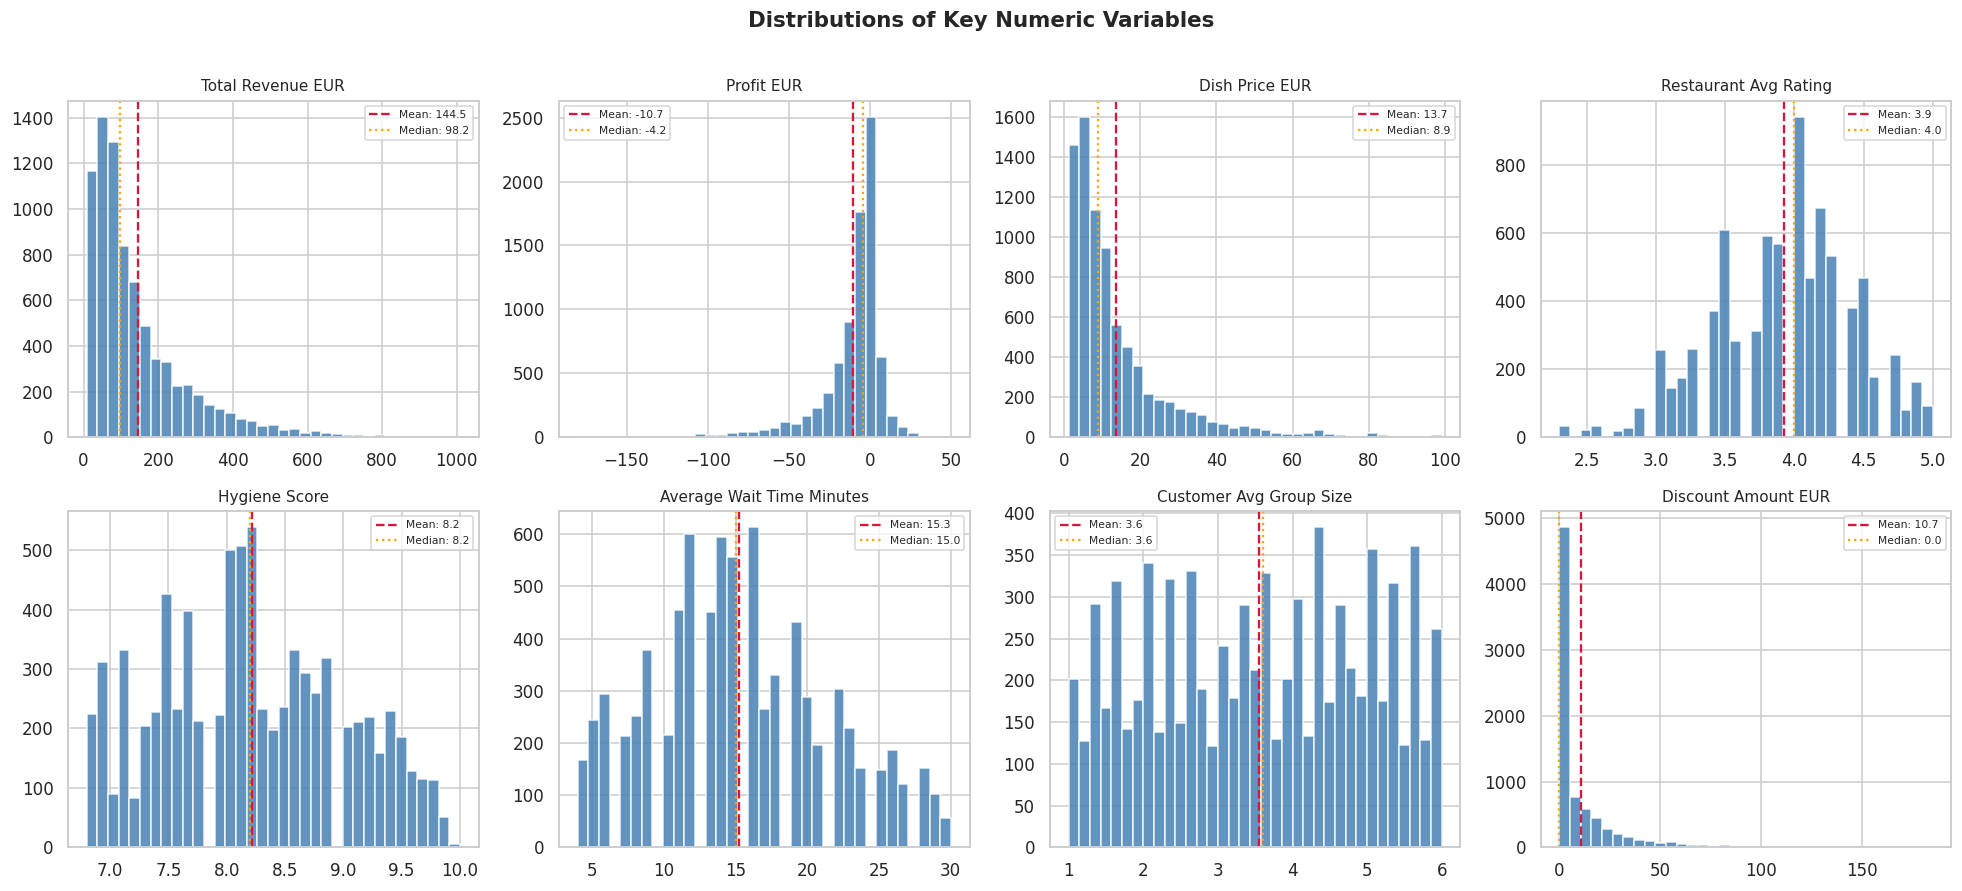

✅ Distributions plotted


In [ ]:
# ─────────────────────────────────────────────
# CELL 5 — Distribution Plots (key variables)
# ─────────────────────────────────────────────
plot_vars = [
    'Total_Revenue_EUR', 'Profit_EUR', 'Dish_Price_EUR',
    'Restaurant_Avg_Rating', 'Hygiene_Score', 'Average_Wait_Time_Minutes',
    'Customer_Avg_Group_Size', 'Discount_Amount_EUR'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, plot_vars):
    data = df[col].dropna()
    ax.hist(data, bins=35, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='crimson', linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle=':', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(col.replace('_', ' '), fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlabel('')

plt.suptitle('Distributions of Key Numeric Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("✅ Distributions plotted")

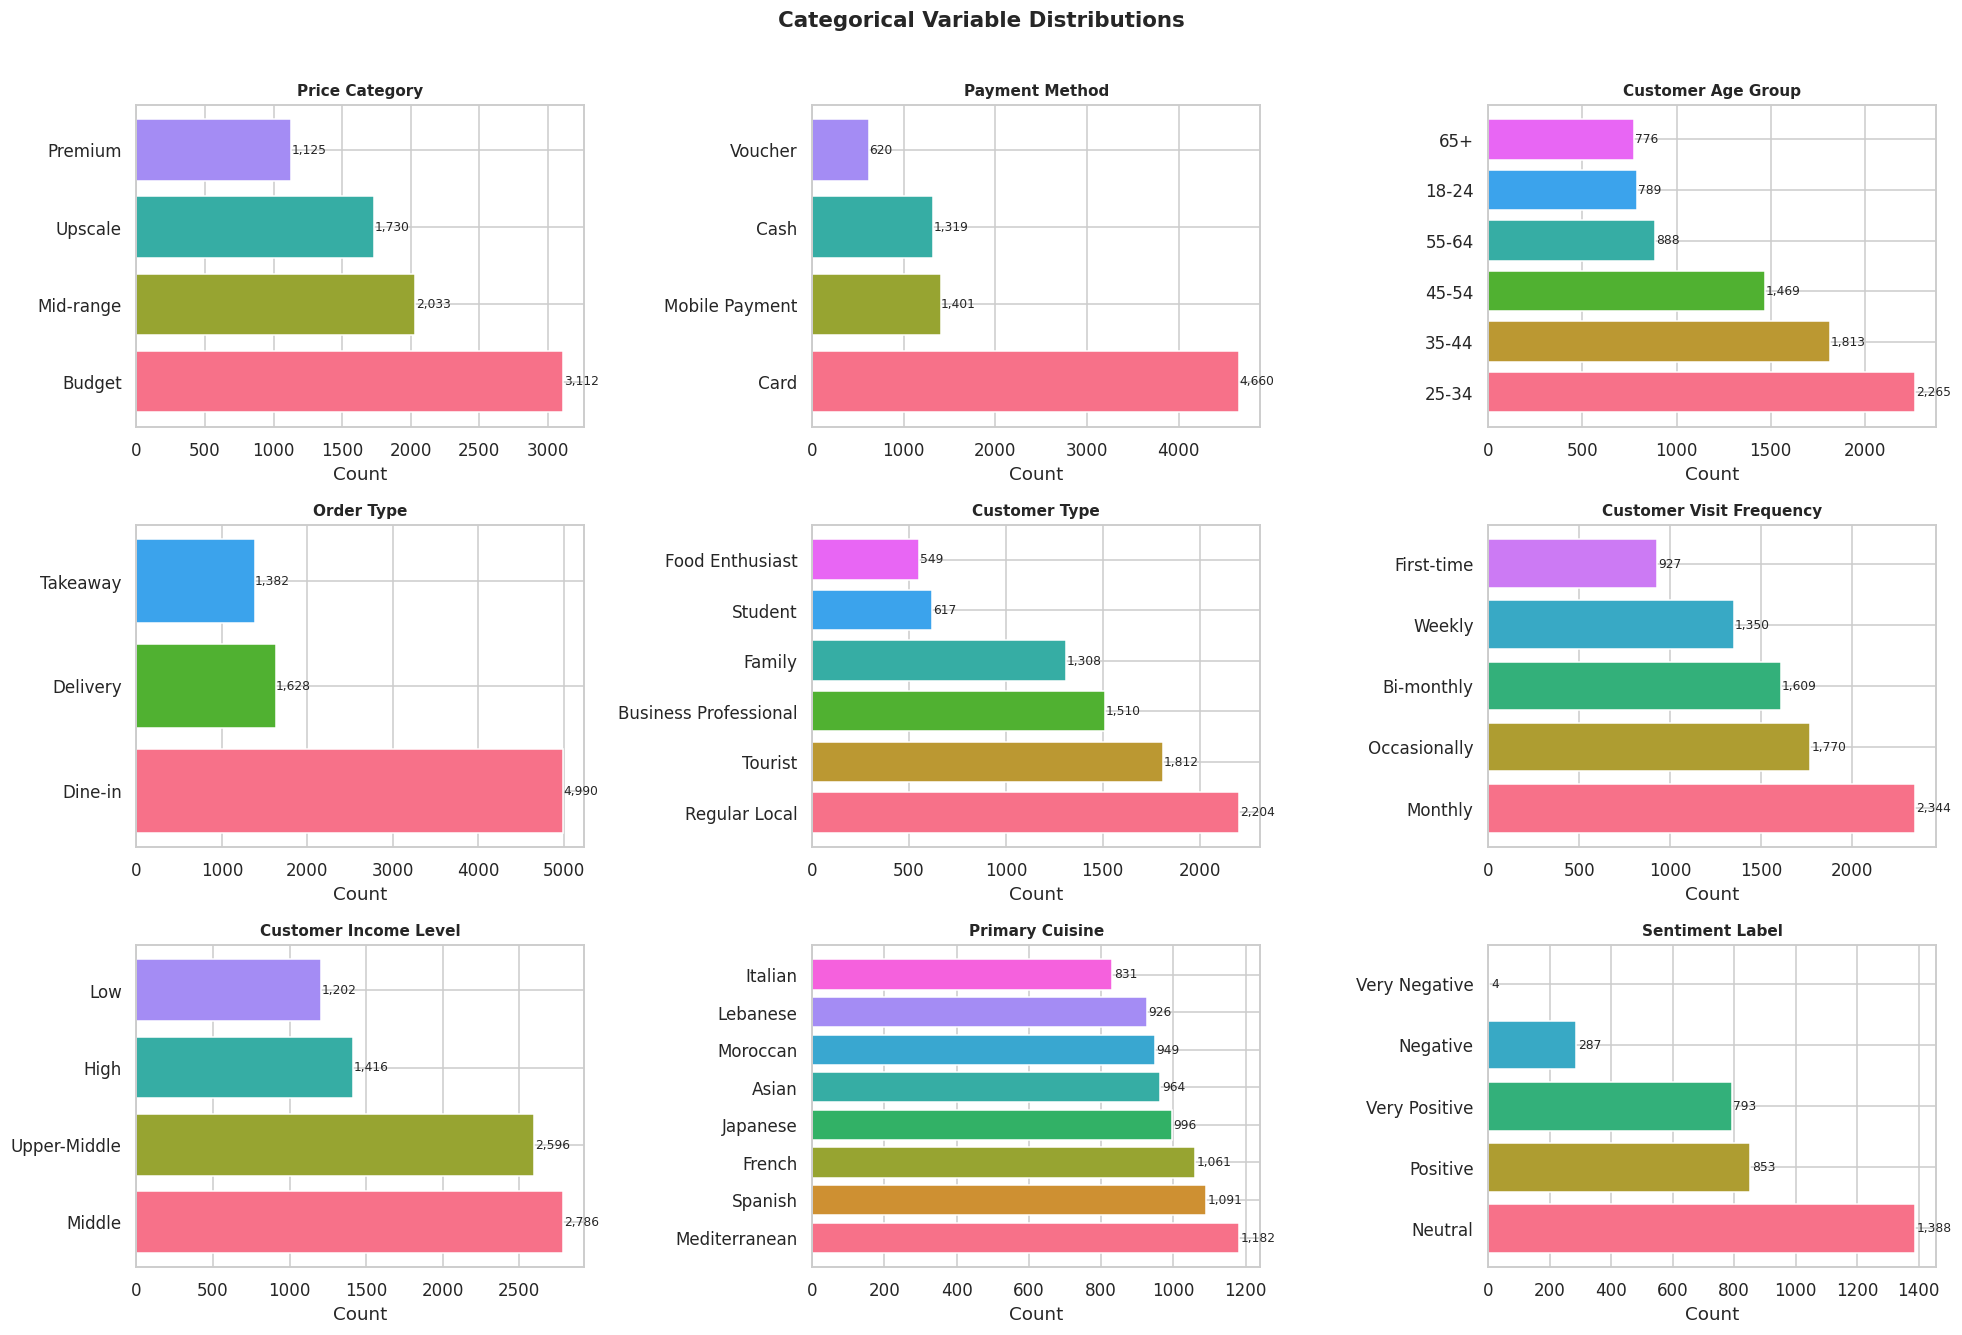

In [ ]:
# ─────────────────────────────────────────────
# CELL 6 — Categorical Overview
# ─────────────────────────────────────────────
cat_cols = [
    'Price_Category', 'Payment_Method', 'Customer_Age_Group',
    'Order_Type', 'Customer_Type', 'Customer_Visit_Frequency',
    'Customer_Income_Level', 'Primary_Cuisine', 'Sentiment_Label'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.barh(counts.index, counts.values, color=sns.color_palette("husl", len(counts)))
    ax.set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    for i, v in enumerate(counts.values):
        ax.text(v + 5, i, f'{v:,}', va='center', fontsize=8)
    ax.set_xlabel('Count')

plt.suptitle('Categorical Variable Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Correlation Analysis

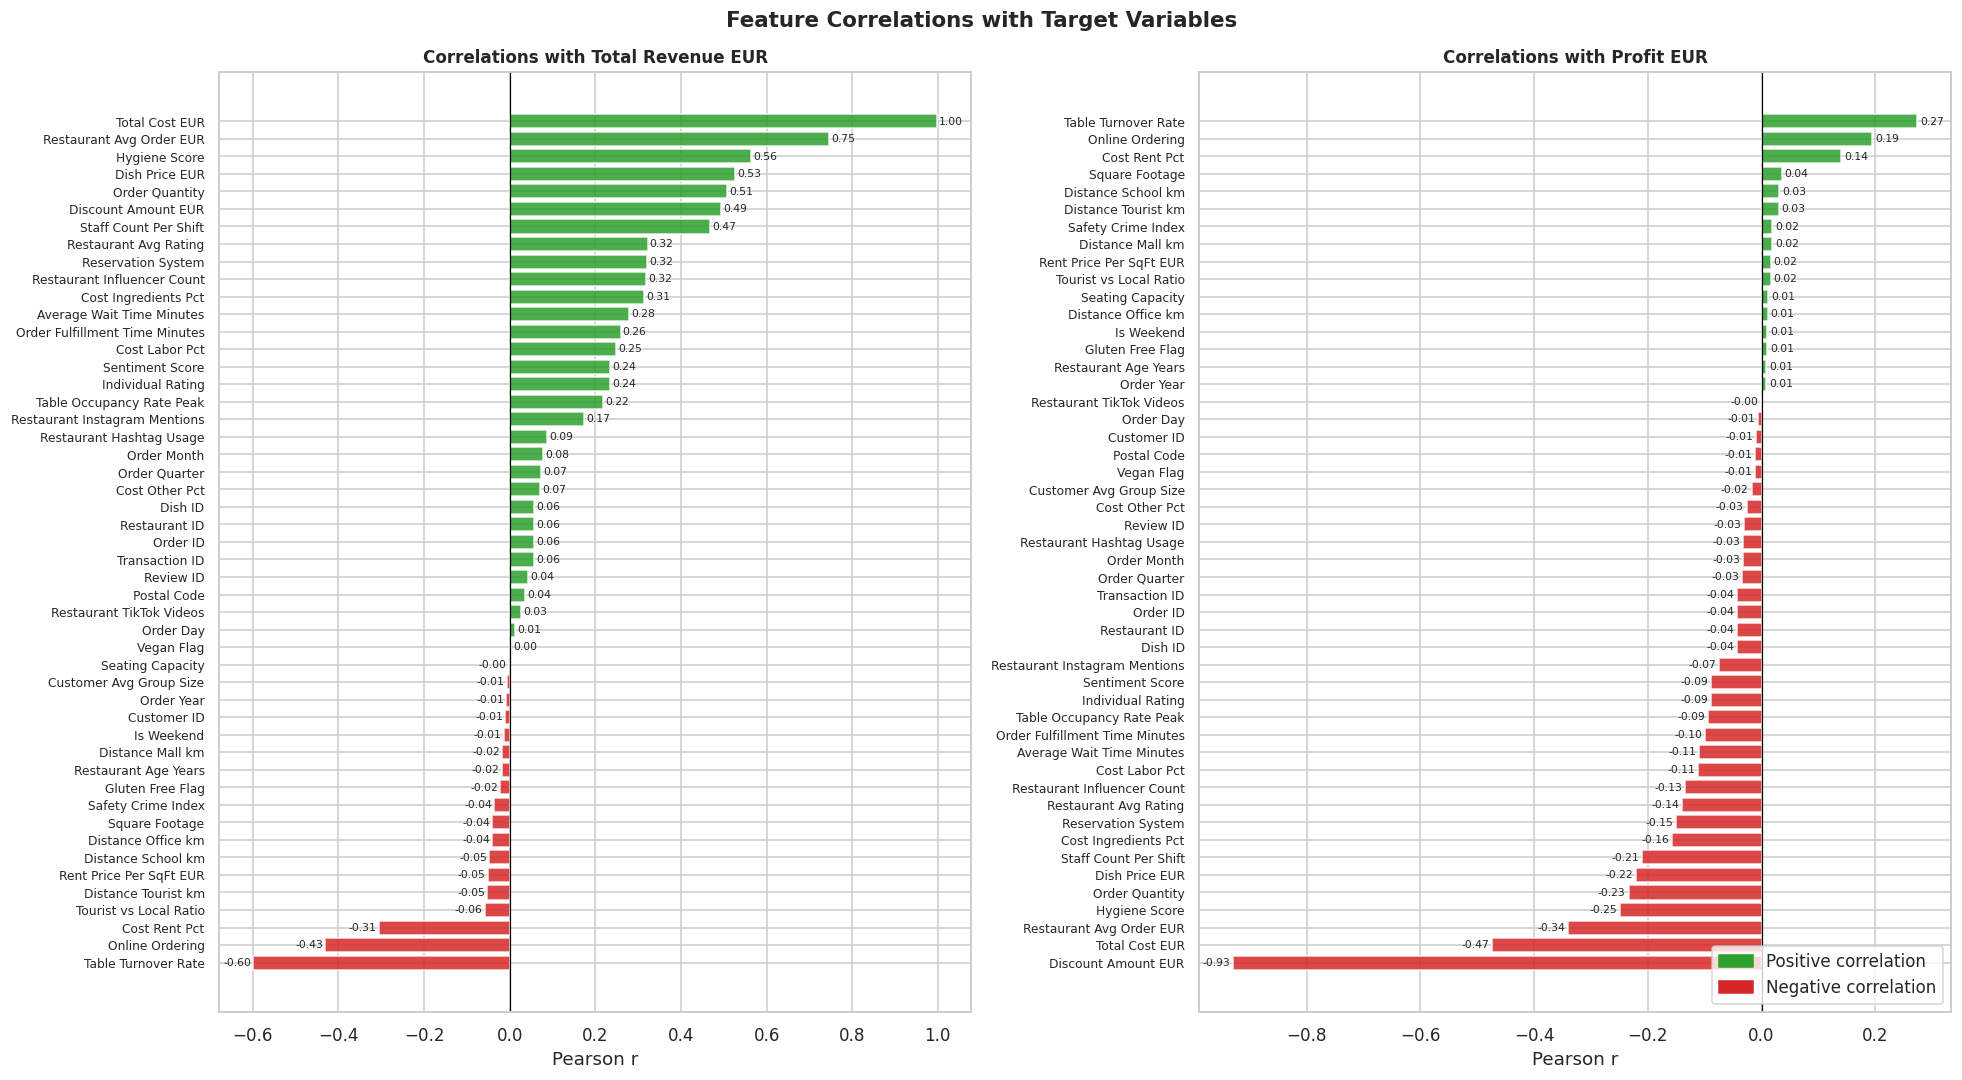

In [ ]:
# ─────────────────────────────────────────────
# CELL 8 — Top Correlations with Target Variables
# ─────────────────────────────────────────────
targets = ['Total_Revenue_EUR', 'Profit_EUR']

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
corr_matrix = df.corr(numeric_only=True)

for ax, target in zip(axes, targets):
    corrs = corr_matrix[target].drop(targets, errors='ignore')
    corrs = corrs.dropna().sort_values()

    # Color bars by sign
    colors = ['#d62728' if v < 0 else '#2ca02c' for v in corrs.values]

    ax.barh(range(len(corrs)), corrs.values, color=colors, alpha=0.85)
    ax.set_yticks(range(len(corrs)))
    ax.set_yticklabels([c.replace('_', ' ') for c in corrs.index], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Correlations with {target.replace("_", " ")}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Pearson r')

    # Annotate values
    for i, v in enumerate(corrs.values):
        ax.text(v + 0.005 if v >= 0 else v - 0.005, i,
                f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=7)

green_patch = mpatches.Patch(color='#2ca02c', label='Positive correlation')
red_patch   = mpatches.Patch(color='#d62728', label='Negative correlation')
plt.legend(handles=[green_patch, red_patch], loc='lower right')
plt.suptitle('Feature Correlations with Target Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

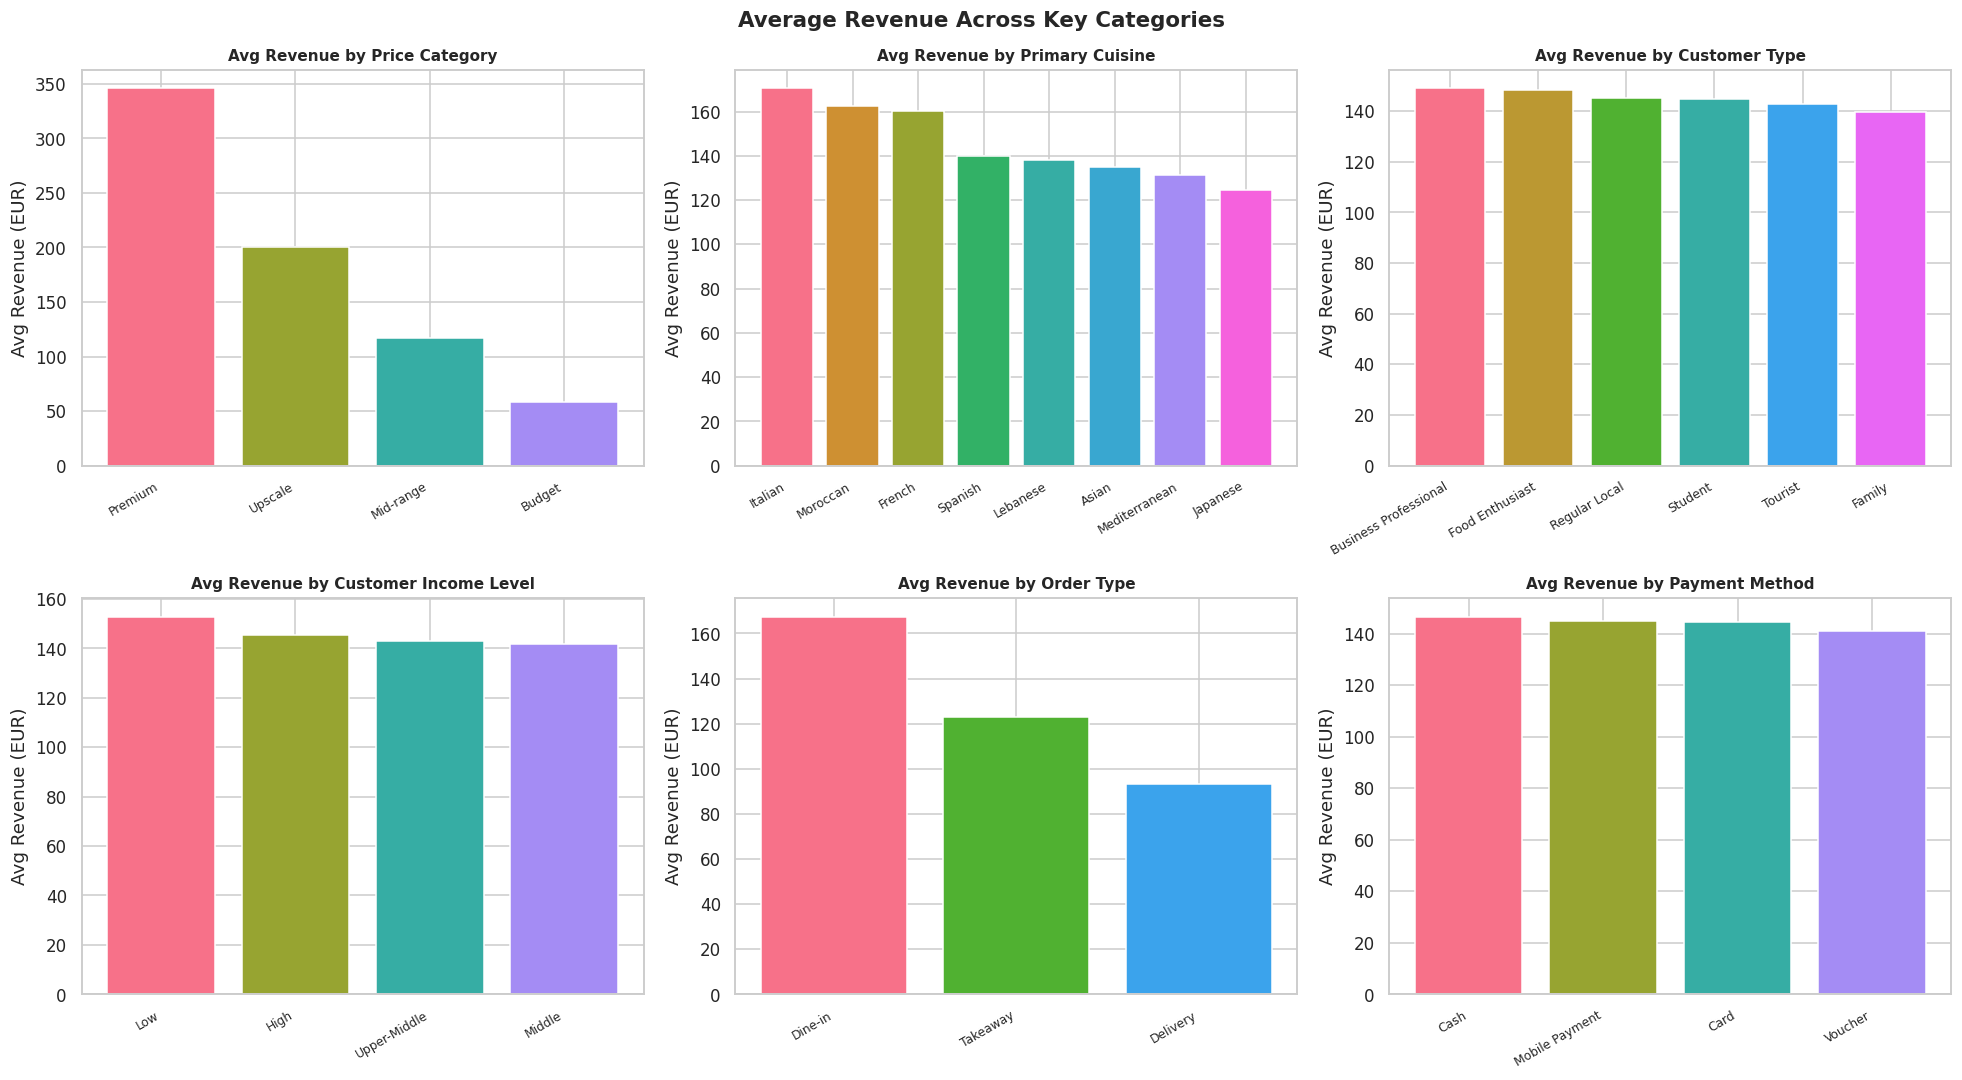

In [ ]:
# ─────────────────────────────────────────────
# CELL 9 — Revenue & Profit by Category
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

group_vars = ['Price_Category', 'Primary_Cuisine', 'Customer_Type',
              'Customer_Income_Level', 'Order_Type', 'Payment_Method']

for ax, gvar in zip(axes.flatten(), group_vars):
    grp = df.groupby(gvar)['Total_Revenue_EUR'].mean().sort_values(ascending=False)
    bars = ax.bar(grp.index, grp.values,
                  color=sns.color_palette("husl", len(grp)), edgecolor='white')
    ax.set_title(f'Avg Revenue by {gvar.replace("_", " ")}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Avg Revenue (EUR)')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Average Revenue Across Key Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing & Feature Engineering

In [ ]:
# ─────────────────────────────────────────────
# CELL 11 — Select Features & Define Targets
# ─────────────────────────────────────────────
# ── Regression target: Total_Revenue_EUR (predicting revenue per transaction)
# ── Classification target: High_Revenue = 1 if revenue > median

REGRESSION_TARGET    = 'Total_Revenue_EUR'
CLASSIFICATION_TARGET = 'High_Revenue'          # created below

# ── Numeric features (no leakage: exclude Revenue, Cost, Profit from features)
NUMERIC_FEATURES = [
    'Dish_Price_EUR', 'Order_Quantity', 'Discount_Amount_EUR',
    'Restaurant_Avg_Rating', 'Seating_Capacity', 'Square_Footage',
    'Restaurant_Age_Years', 'Foot_Traffic_Volume', 'Rent_Price_Per_SqFt_EUR',
    'Safety_Crime_Index', 'Distance_Office_km', 'Distance_School_km',
    'Distance_Mall_km', 'Distance_Tourist_km',
    'Customer_Avg_Group_Size', 'Staff_Count_Per_Shift',
    'Average_Wait_Time_Minutes', 'Order_Fulfillment_Time_Minutes',
    'Table_Occupancy_Rate_Peak', 'Table_Turnover_Rate', 'Hygiene_Score',
    'Cost_Ingredients_Pct', 'Cost_Rent_Pct', 'Cost_Labor_Pct', 'Cost_Other_Pct',
    'Restaurant_Instagram_Mentions', 'Restaurant_TikTok_Videos',
    'Restaurant_Influencer_Count', 'Restaurant_Hashtag_Usage',
    'Tourist_vs_Local_Ratio', 'Is_Weekend',
    'Vegan_Flag', 'Gluten_Free_Flag', 'Reservation_System', 'Online_Ordering',
    'Order_Month', 'Order_Quarter'
]

# ── Categorical features (will be label-encoded)
CATEGORICAL_FEATURES = [
    'Price_Category', 'Primary_Cuisine', 'Secondary_Cuisine',
    'Customer_Age_Group', 'Customer_Income_Level', 'Customer_Type',
    'Customer_Visit_Frequency', 'Order_Type', 'Payment_Method',
    'Discount_Type', 'Order_Channel', 'Dish_Category',
    'Neighborhood', 'Parking_Available'
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"📌 Regression target  : {REGRESSION_TARGET}")
print(f"📌 Classification target: {CLASSIFICATION_TARGET}")
print(f"📌 Numeric features   : {len(NUMERIC_FEATURES)}")
print(f"📌 Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"📌 Total features     : {len(ALL_FEATURES)}")

📌 Regression target  : Total_Revenue_EUR
📌 Classification target: High_Revenue
📌 Numeric features   : 37
📌 Categorical features: 14
📌 Total features     : 51


In [ ]:
# ─────────────────────────────────────────────
# CELL 12 — Clean & Encode
# ─────────────────────────────────────────────
model_df = df[ALL_FEATURES + [REGRESSION_TARGET]].copy()

# ── Create classification target
median_rev = df[REGRESSION_TARGET].median()
model_df[CLASSIFICATION_TARGET] = (df[REGRESSION_TARGET] > median_rev).astype(int)
print(f"📊 Classification target (High_Revenue > €{median_rev:.0f}):")
print(model_df[CLASSIFICATION_TARGET].value_counts())
print(f"   Balance: {model_df[CLASSIFICATION_TARGET].mean()*100:.1f}% positive")

# ── Fill missing numerics with median
for col in NUMERIC_FEATURES:
    if model_df[col].isnull().any():
        model_df[col] = model_df[col].fillna(model_df[col].median())

# ── Label-encode categoricals
le = LabelEncoder()
for col in CATEGORICAL_FEATURES:
    model_df[col] = model_df[col].fillna('Unknown')
    model_df[col] = le.fit_transform(model_df[col].astype(str))

# Final check
print(f"\n✅ Processed dataset: {model_df.shape}")
print(f"   Missing values remaining: {model_df.isnull().sum().sum()}")

📊 Classification target (High_Revenue > €98):
High_Revenue
1    4000
0    4000
Name: count, dtype: int64
   Balance: 50.0% positive

✅ Processed dataset: (8000, 53)
   Missing values remaining: 0


In [ ]:
# ─────────────────────────────────────────────
# CELL 13 — FINAL Clean Train/Test + Encoding + Scaling
# ─────────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Features & targets
X = model_df[ALL_FEATURES].copy()
y_reg   = model_df[REGRESSION_TARGET]
y_class = model_df[CLASSIFICATION_TARGET]

# ── ONE consistent split
X_train, X_test, y_reg_train, y_reg_test, y_class_train, y_class_test = train_test_split(
    X, y_reg, y_class,
    test_size=0.20,
    random_state=42
)

# ─────────────────────────────
# 🔧 STEP 1 — Encode ALL categorical columns automatically
# ─────────────────────────────
cat_cols = X_train.select_dtypes(include=['object']).columns

print(f"Encoding {len(cat_cols)} categorical columns...")

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)

# Align columns (VERY IMPORTANT)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ─────────────────────────────
# 🔧 STEP 2 — Ensure everything is numeric
# ─────────────────────────────
print("Checking remaining non-numeric columns:")
remaining = X_train.select_dtypes(include=['object']).columns
print(list(remaining))   # should be empty []

# ─────────────────────────────
# 🔧 STEP 3 — Scale features (NO leakage)
# ─────────────────────────────
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_train.columns, index=X_test.index)

# ── Assign for regression
X_train_r, X_test_r = X_train_scaled, X_test_scaled
y_train_r, y_test_r = y_reg_train, y_reg_test

# ── Assign for classification
X_train_c, X_test_c = X_train_scaled, X_test_scaled
y_train_c, y_test_c = y_class_train, y_class_test

# ─────────────────────────────
# ✅ Summary
# ─────────────────────────────
print("\n✅ Train/Test split + encoding + scaling COMPLETE")
print(f"   Train size: {X_train.shape[0]:,}")
print(f"   Test size : {X_test.shape[0]:,}")
print(f"   Features after encoding: {X_train.shape[1]}")

print("\n📊 Classification balance:")
print(f"   Train positive rate: {y_train_c.mean()*100:.1f}%")
print(f"   Test  positive rate: {y_test_c.mean()*100:.1f}%")

Encoding 1 categorical columns...
Checking remaining non-numeric columns:
[]

✅ Train/Test split + encoding + scaling COMPLETE
   Train size: 6,400
   Test size : 1,600
   Features after encoding: 53

📊 Classification balance:
   Train positive rate: 49.7%
   Test  positive rate: 51.4%


## 5. Regression Models & Comparison

Predicting `Total_Revenue_EUR` using **Linear Regression**, **Random Forest**, and **Gradient Boosting** (80/20 split).

In [ ]:
# ─────────────────────────────────────────────
# CELL 14 — Helper: evaluate_regressor
# ─────────────────────────────────────────────
def evaluate_regressor(name, model, X_tr, X_te, y_tr, y_te):
    """Fit, predict and return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2   = r2_score(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    # 5-fold CV R²
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')

    print(f"{'─'*50}")
    print(f"  {name}")
    print(f"  R²         : {r2:.4f}")
    print(f"  MAE        : {mae:.2f} EUR")
    print(f"  RMSE       : {rmse:.2f} EUR")
    print(f"  CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    return {
        'Model': name, 'R²': r2, 'MAE': mae, 'RMSE': rmse,
        'CV R² Mean': cv_scores.mean(), 'CV R² Std': cv_scores.std(),
        'y_pred': y_pred, 'fitted': model
    }

print("✅ evaluate_regressor helper defined")

✅ evaluate_regressor helper defined


In [ ]:
# ─────────────────────────────────────────────
# CELL 15 — Linear Regression
# ─────────────────────────────────────────────
print("\n🔵 LINEAR REGRESSION")
lr_result = evaluate_regressor(
    "Linear Regression",
    LinearRegression(),
    X_train_r, X_test_r, y_train_r, y_test_r
)


🔵 LINEAR REGRESSION
──────────────────────────────────────────────────
  Linear Regression
  R²         : 0.7746
  MAE        : 45.17 EUR
  RMSE       : 68.51 EUR
  CV R² (5-fold): 0.7751 ± 0.0069


In [ ]:
# ─────────────────────────────────────────────
# CELL 16 — Random Forest Regressor
# ─────────────────────────────────────────────
print("\n🟢 RANDOM FOREST REGRESSOR")
rf_result = evaluate_regressor(
    "Random Forest",
    RandomForestRegressor(n_estimators=200, max_depth=15,
                          min_samples_leaf=5, random_state=42, n_jobs=-1),
    X_train_r, X_test_r, y_train_r, y_test_r
)


🟢 RANDOM FOREST REGRESSOR
──────────────────────────────────────────────────
  Random Forest
  R²         : 0.9307
  MAE        : 22.18 EUR
  RMSE       : 38.00 EUR
  CV R² (5-fold): 0.9235 ± 0.0050


In [ ]:
# ─────────────────────────────────────────────
# CELL 17 — Gradient Boosting Regressor
# ─────────────────────────────────────────────
print("\n🔴 GRADIENT BOOSTING REGRESSOR")
gb_result = evaluate_regressor(
    "Gradient Boosting",
    GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                               max_depth=5, subsample=0.8, random_state=42),
    X_train_r, X_test_r, y_train_r, y_test_r
)


🔴 GRADIENT BOOSTING REGRESSOR
──────────────────────────────────────────────────
  Gradient Boosting
  R²         : 0.9541
  MAE        : 18.16 EUR
  RMSE       : 30.93 EUR
  CV R² (5-fold): 0.9545 ± 0.0031


In [ ]:
# ─────────────────────────────────────────────
# CELL 18 — Regression Model Comparison Table
# ─────────────────────────────────────────────
results = [lr_result, rf_result, gb_result]
reg_compare = pd.DataFrame([{k: v for k, v in r.items()
                              if k not in ('y_pred','fitted')}
                             for r in results])

reg_compare = reg_compare.set_index('Model')
print("\n📊 REGRESSION MODEL COMPARISON")
print("=" * 60)
print(reg_compare[['R²','MAE','RMSE','CV R² Mean','CV R² Std']].to_string())

best_model_name = reg_compare['R²'].idxmax()
print(f"\n🏆 Best model by R²: {best_model_name} "
      f"(R² = {reg_compare.loc[best_model_name,'R²']:.4f})")


📊 REGRESSION MODEL COMPARISON
                    R²   MAE  RMSE  CV R² Mean  CV R² Std
Model                                                    
Linear Regression 0.77 45.17 68.51        0.78       0.01
Random Forest     0.93 22.18 38.00        0.92       0.01
Gradient Boosting 0.95 18.16 30.93        0.95       0.00

🏆 Best model by R²: Gradient Boosting (R² = 0.9541)


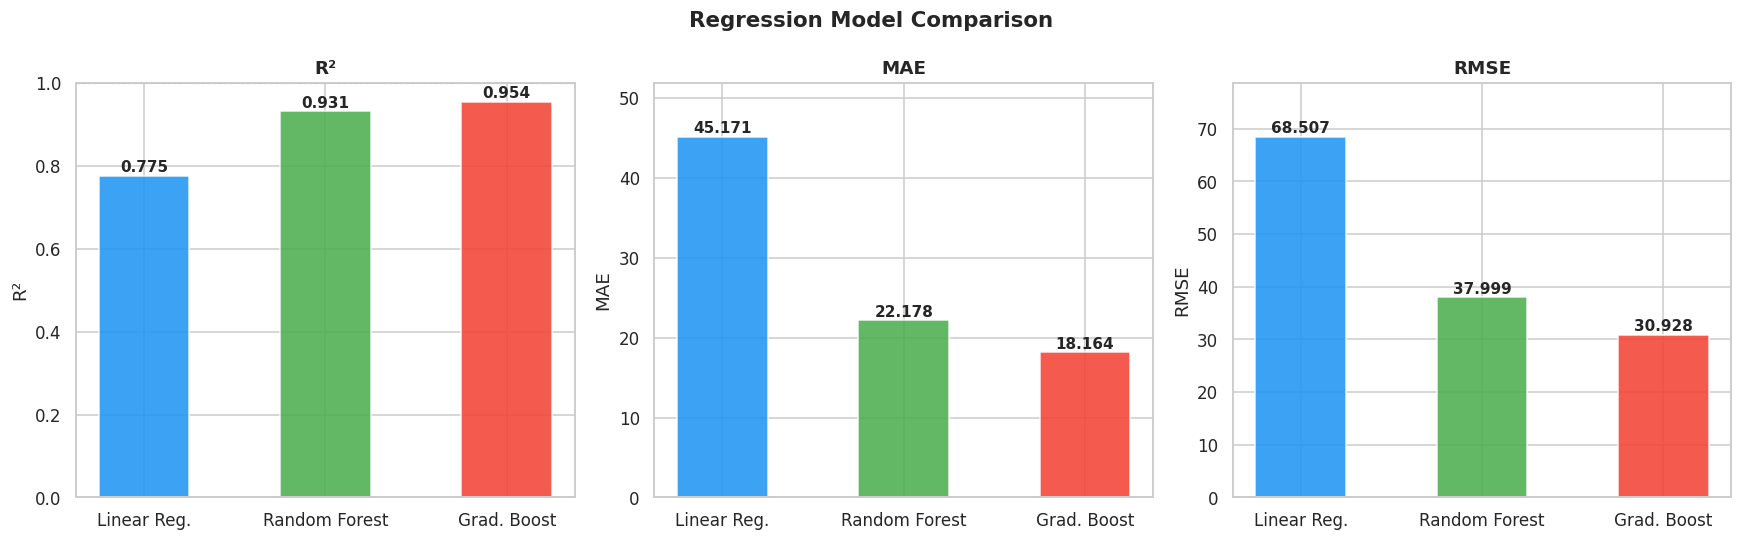

In [ ]:
# ─────────────────────────────────────────────
# CELL 19 — Regression Comparison Bar Charts
# ─────────────────────────────────────────────
metrics_to_plot = ['R²', 'MAE', 'RMSE']
colors = ['#2196F3', '#4CAF50', '#F44336']
models_labels = ['Linear Reg.', 'Random Forest', 'Grad. Boost']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics_to_plot):
    vals = reg_compare[metric].values
    bars = ax.bar(models_labels, vals, color=colors, edgecolor='white',
                  width=0.5, alpha=0.88)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.15)
    # For R², higher is better; for MAE/RMSE, lower is better
    if metric == 'R²':
        ax.set_ylim(0, 1.0)
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.7)

plt.suptitle('Regression Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

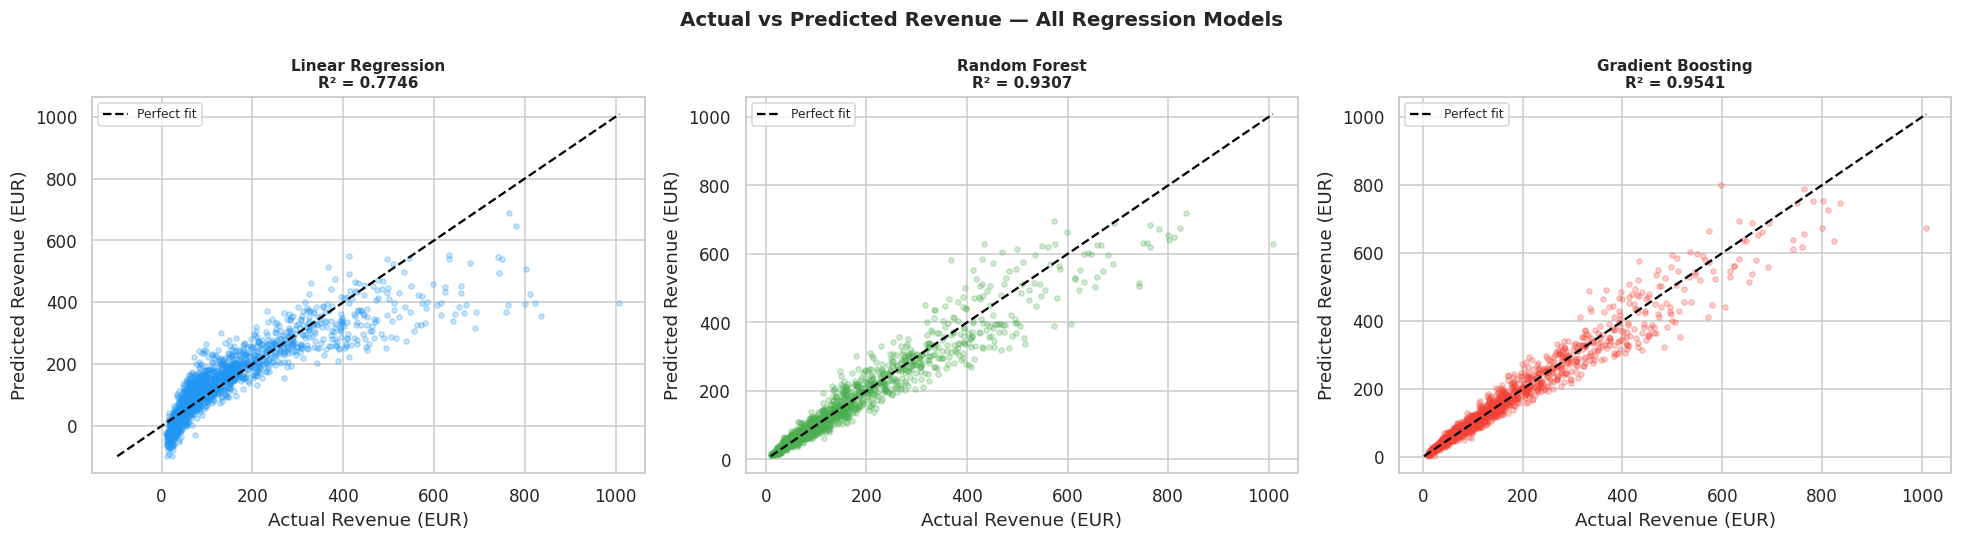

In [ ]:
# ─────────────────────────────────────────────
# CELL 20 — Actual vs Predicted Plots
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res, color in zip(axes, results, colors):
    y_pred = res['y_pred']
    y_true = y_test_r.values
    ax.scatter(y_true, y_pred, alpha=0.25, s=12, color=color)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f"{res['Model']}\nR² = {res['R²']:.4f}", fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual Revenue (EUR)')
    ax.set_ylabel('Predicted Revenue (EUR)')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Revenue — All Regression Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Classification Models & Comparison

Predicting `High_Revenue` (whether revenue > median) using **Logistic Regression (Logit)** and **Probit**.

In [ ]:
# ─────────────────────────────────────────────
# CELL 22 — Helper: evaluate_classifier
# ─────────────────────────────────────────────
def evaluate_classifier(name, model, X_tr, X_te, y_tr, y_te,
                         use_predict_proba=True):
    """Fit, predict, print and return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)

    if use_predict_proba and hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_te)
    else:
        y_prob = y_pred  # fallback

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='binary')
    try:
        auc  = roc_auc_score(y_te, y_prob)
    except Exception:
        auc = float('nan')

    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy')

    print(f"{'─'*50}")
    print(f"  {name}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  F1 Score    : {f1:.4f}")
    print(f"  AUC-ROC     : {auc:.4f}")
    print(f"  CV Acc (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print()
    print(classification_report(y_te, y_pred,
                                 target_names=['Low Revenue','High Revenue']))

    return {
        'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc,
        'CV Acc Mean': cv_scores.mean(), 'CV Acc Std': cv_scores.std(),
        'y_pred': y_pred, 'y_prob': y_prob, 'fitted': model
    }

print("✅ evaluate_classifier helper defined")

✅ evaluate_classifier helper defined


In [ ]:
# ─────────────────────────────────────────────
# CELL 23 — Logistic Regression (Logit)
# ─────────────────────────────────────────────
print("\n🔵 LOGISTIC REGRESSION (LOGIT)")
logit_result = evaluate_classifier(
    "Logit (Logistic Regression)",
    LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42),
    X_train_c, X_test_c, y_train_c, y_test_c
)


🔵 LOGISTIC REGRESSION (LOGIT)
──────────────────────────────────────────────────
  Logit (Logistic Regression)
  Accuracy    : 0.9025
  F1 Score    : 0.9052
  AUC-ROC     : 0.9749
  CV Acc (5-fold): 0.8983 ± 0.0087

              precision    recall  f1-score   support

 Low Revenue       0.90      0.90      0.90       778
High Revenue       0.90      0.91      0.91       822

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



In [ ]:
# ─────────────────────────────────────────────
# CELL 24 — Probit Model (FIXED VERSION)
# ─────────────────────────────────────────────

print("\n🟡 PROBIT MODEL (statsmodels)")

import statsmodels.api as sm
import pandas as pd
import numpy as np

# ── Add constant (intercept)
X_train_sm = sm.add_constant(X_train_c.values)
X_test_sm  = sm.add_constant(X_test_c.values)

# ── Fit Probit model
probit_sm = sm.Probit(y_train_c.values, X_train_sm)
probit_fit = probit_sm.fit(disp=False)

# ─────────────────────────────────────────────
# FIX: use correct feature names (NOT ALL_FEATURES)
# ─────────────────────────────────────────────
feature_names = X_train_c.columns

# ── Build coefficient table safely
summary_df = pd.DataFrame({
    'Coef': probit_fit.params[1:],      # skip intercept
    'Std Err': probit_fit.bse[1:],
    'z': probit_fit.tvalues[1:],
    'p-value': probit_fit.pvalues[1:]
}, index=feature_names)

summary_df['|z|'] = summary_df['z'].abs()

print("\n📋 Probit Marginal Effects (Top 15 by |z|):")
print(summary_df.sort_values('|z|', ascending=False).head(15).to_string())

# ─────────────────────────────────────────────
# Predictions
# ─────────────────────────────────────────────
y_prob_probit = probit_fit.predict(X_test_sm)
y_pred_probit = (y_prob_probit >= 0.5).astype(int)

# ─────────────────────────────────────────────
# Metrics
# ─────────────────────────────────────────────
acc_probit = accuracy_score(y_test_c, y_pred_probit)
f1_probit  = f1_score(y_test_c, y_pred_probit)
auc_probit = roc_auc_score(y_test_c, y_prob_probit)

print(f"\n{'─'*50}")
print("  Probit Model (statsmodels)")
print(f"  Accuracy    : {acc_probit:.4f}")
print(f"  F1 Score    : {f1_probit:.4f}")
print(f"  AUC-ROC     : {auc_probit:.4f}")
print(f"  Pseudo R²   : {probit_fit.prsquared:.4f}")
print()
print(classification_report(y_test_c, y_pred_probit,
                             target_names=['Low Revenue','High Revenue']))

# ─────────────────────────────────────────────
# Store results
# ─────────────────────────────────────────────
probit_result = {
    'Model': 'Probit',
    'Accuracy': acc_probit,
    'F1': f1_probit,
    'AUC': auc_probit,
    'CV Acc Mean': np.nan,
    'CV Acc Std': np.nan,
    'y_pred': y_pred_probit,
    'y_prob': y_prob_probit,
    'fitted': probit_fit
}


🟡 PROBIT MODEL (statsmodels)

📋 Probit Marginal Effects (Top 15 by |z|):
                            Coef  Std Err      z  p-value   |z|
Order_Quantity              1.86     0.06  31.88     0.00 31.88
Discount_Amount_EUR         1.42     0.12  12.11     0.00 12.11
Table_Turnover_Rate        -0.63     0.06 -11.28     0.00 11.28
Seating_Capacity           -0.64     0.06 -10.25     0.00 10.25
Discount_Type               0.50     0.05   9.66     0.00  9.66
Price_Category              0.78     0.09   9.01     0.00  9.01
Hygiene_Score               0.36     0.05   7.38     0.00  7.38
Square_Footage              0.25     0.04   6.25     0.00  6.25
Staff_Count_Per_Shift       0.44     0.08   5.42     0.00  5.42
Dish_Price_EUR              0.23     0.05   5.15     0.00  5.15
Online_Ordering             0.21     0.04   5.01     0.00  5.01
Foot_Traffic_Volume_Medium -0.32     0.06  -4.91     0.00  4.91
Foot_Traffic_Volume_Low    -0.42     0.09  -4.88     0.00  4.88
Order_Type                 -0.

In [ ]:
# ─────────────────────────────────────────────
# CELL 25 — Classification Comparison Table
# ─────────────────────────────────────────────
clf_results = [logit_result, probit_result]
clf_compare = pd.DataFrame([{k: v for k, v in r.items()
                              if k not in ('y_pred','y_prob','fitted')}
                             for r in clf_results]).set_index('Model')

print("\n📊 CLASSIFICATION MODEL COMPARISON")
print("=" * 60)
print(clf_compare[['Accuracy','F1','AUC','CV Acc Mean','CV Acc Std']].to_string())

best_clf = clf_compare['AUC'].idxmax()
print(f"\n🏆 Best model by AUC: {best_clf} "
      f"(AUC = {clf_compare.loc[best_clf,'AUC']:.4f})")


📊 CLASSIFICATION MODEL COMPARISON
                             Accuracy   F1  AUC  CV Acc Mean  CV Acc Std
Model                                                                   
Logit (Logistic Regression)      0.90 0.91 0.97         0.90        0.01
Probit                           0.90 0.90 0.97          NaN         NaN

🏆 Best model by AUC: Logit (Logistic Regression) (AUC = 0.9749)


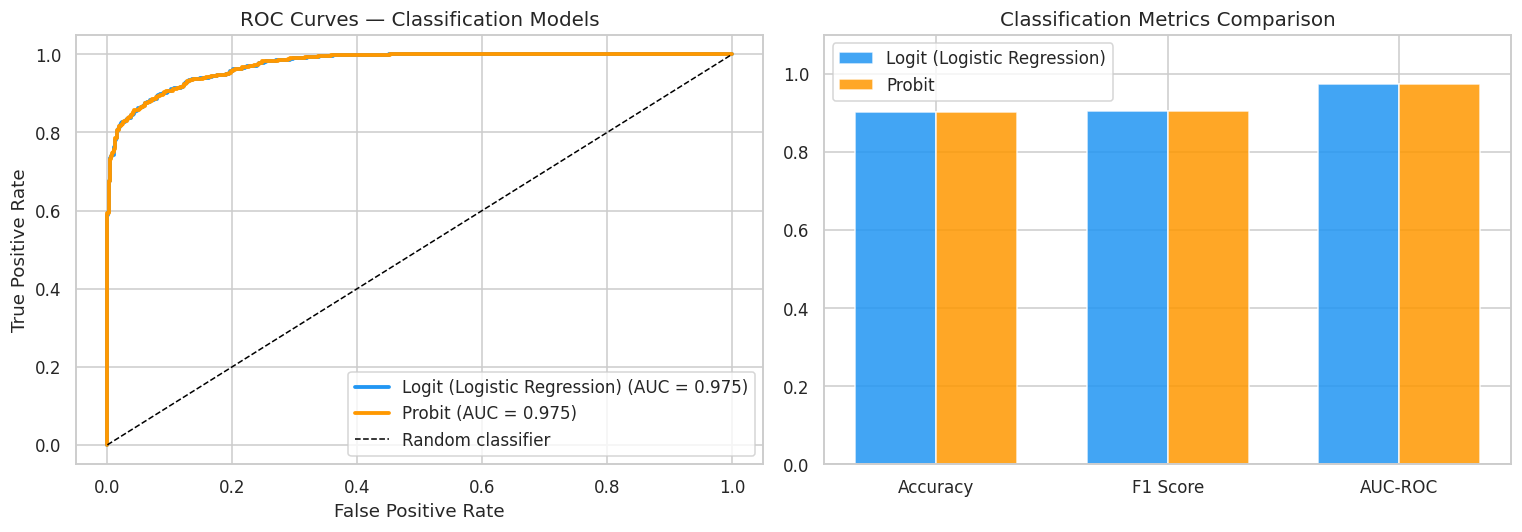

In [ ]:
# ─────────────────────────────────────────────
# CELL 26 — ROC Curves + Metrics Comparison (FIXED)
# ─────────────────────────────────────────────

from sklearn.metrics import roc_curve, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clf_colors = ['#2196F3', '#FF9800']
clf_results = [logit_result, probit_result]
# ─────────────────────────────────────────────
# LEFT: ROC CURVES
# ─────────────────────────────────────────────
ax = axes[0]

for res, col in zip(clf_results, clf_colors):
    fpr, tpr, _ = roc_curve(y_test_c, res['y_prob'])
    ax.plot(fpr, tpr, color=col, linewidth=2.5,
            label=f"{res['Model']} (AUC = {res['AUC']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Classification Models')
ax.legend()

# ─────────────────────────────────────────────
# RIGHT: METRICS COMPARISON (FIXED)
# ─────────────────────────────────────────────
ax = axes[1]

metrics_names = ['Accuracy', 'F1 Score', 'AUC-ROC']
x = np.arange(len(metrics_names))
bar_width = 0.35

for i, (res, col) in enumerate(zip(clf_results, clf_colors)):
    values = [res['Accuracy'], res['F1'], res['AUC']]
    ax.bar(x + (i - 0.5)*bar_width, values,
           width=bar_width,
           label=res['Model'],
           color=col,
           alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.1)
ax.set_title('Classification Metrics Comparison')
ax.legend()

plt.tight_layout()
plt.show()

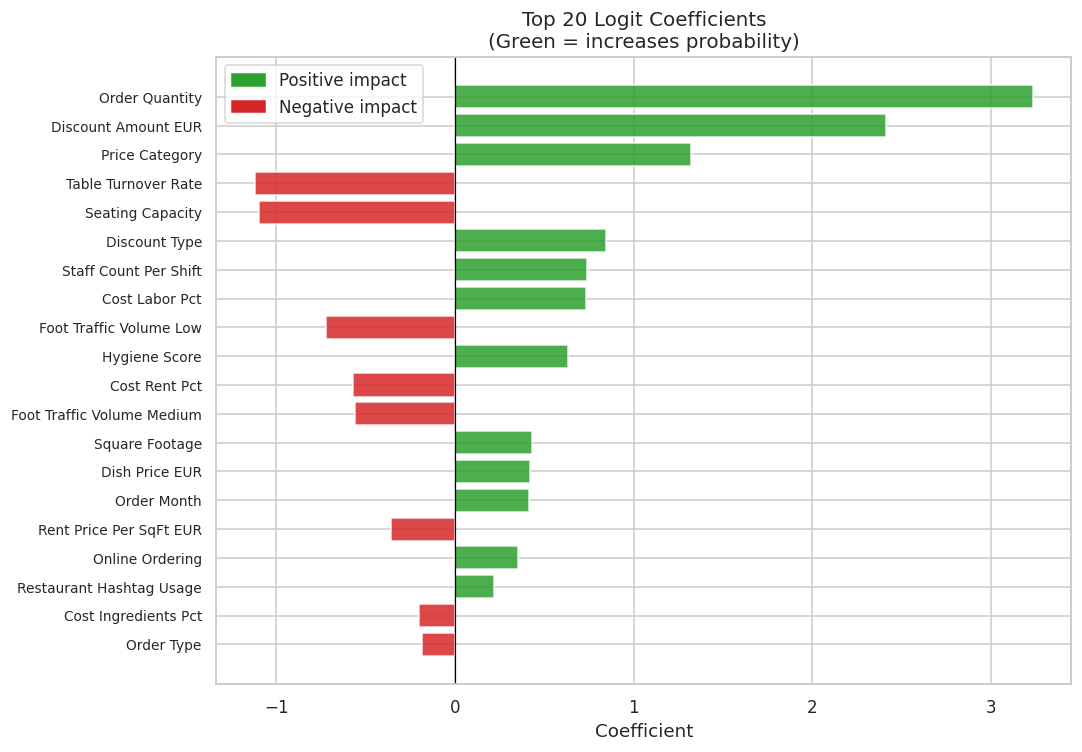


📋 Top 10 Logit Features by |Coefficient|:
                Feature  Coefficient  Odds Ratio
         Order_Quantity         3.23       25.32
    Discount_Amount_EUR         2.41       11.16
         Price_Category         1.32        3.75
    Table_Turnover_Rate        -1.12        0.33
       Seating_Capacity        -1.10        0.33
          Discount_Type         0.84        2.32
  Staff_Count_Per_Shift         0.74        2.09
         Cost_Labor_Pct         0.74        2.09
Foot_Traffic_Volume_Low        -0.72        0.49
          Hygiene_Score         0.63        1.88


In [ ]:
# ─────────────────────────────────────────────
# CELL 28 — Logit Coefficients (FIXED + SAFE)
# ─────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Get trained model
logit_model = logit_result['fitted']

# ─────────────────────────────────────────────
# IMPORTANT FIX:
# Use actual training feature names (NOT ALL_FEATURES)
# ─────────────────────────────────────────────
feature_names = X_train_c.columns  # OR X_train_r.columns (same scaled matrix)

# Safety check (prevents silent mismatch)
assert len(feature_names) == len(logit_model.coef_[0]), \
    "Feature mismatch between model and dataset!"

# ── Build coefficient table
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': logit_model.coef_[0],
    'Odds Ratio': np.exp(logit_model.coef_[0])
})

# ── Sort by absolute importance
coef_df = coef_df.reindex(
    coef_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#2ca02c' if v > 0 else '#d62728' for v in coef_df['Coefficient']]

ax.barh(
    range(len(coef_df)),
    coef_df['Coefficient'][::-1],
    color=colors[::-1],
    alpha=0.85
)

ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(
    coef_df['Feature'][::-1].str.replace('_', ' '),
    fontsize=9
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Logit Coefficients\n(Green = increases probability)')
ax.set_xlabel('Coefficient')

# Legend
green_p = mpatches.Patch(color='#2ca02c', label='Positive impact')
red_p = mpatches.Patch(color='#d62728', label='Negative impact')
ax.legend(handles=[green_p, red_p])

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# Top 10 table
# ─────────────────────────────────────────────
print("\n📋 Top 10 Logit Features by |Coefficient|:")
print(
    coef_df[['Feature', 'Coefficient', 'Odds Ratio']]
    .head(10)
    .to_string(index=False)
)